Initialized MLflow to track repo "SamuelFredricBerg/4dt907"

Repository SamuelFredricBerg/4dt907 initialized!

📁 Total Files: 358
🔒 Test Files (35): ['A28_kinect.csv', 'A116_kinect.csv', 'A16_kinect.csv', 'A61_kinect.csv', 'A26_kinect.csv', 'A119_kinect.csv', 'A69_kinect.csv', 'A123_kinect.csv', 'A17_kinect.csv', 'A96_kinect.csv', 'A142_kinect.csv', 'A13_kinect.csv', 'A58_kinect.csv', 'A31_kinect.csv', 'A18_kinect.csv', 'A115_kinect.csv', 'A5_kinect.csv', 'B18_kinect.csv', 'A19_kinect.csv', 'A65_kinect.csv', 'A87_kinect.csv', 'A129_kinect.csv', 'A10_kinect.csv', 'A66_kinect.csv', 'A99_kinect.csv', 'A118_kinect.csv', 'A78_kinect.csv', 'A1_kinect.csv', 'A43_kinect.csv', 'A6_kinect.csv', 'A46_kinect.csv', 'B20_kinect.csv', 'A48_kinect.csv', 'A84_kinect.csv', 'A128_kinect.csv']
🧪 Val Files:  70
✅ Train Files: 218
Epoch 0: Train MSE 0.009391, Val MAE 0.056036
Epoch 1: Train MSE 0.005097, Val MAE 0.049637
Epoch 2: Train MSE 0.003041, Val MAE 0.043160
Epoch 3: Train MSE 0.002120, Val MAE 0.053068
Epoch 4: Train MSE 0.002025, Val MAE 0.044363
Epoch 5: Train MSE 0.001154, Val MAE 0.039883
Epoch 6: Train

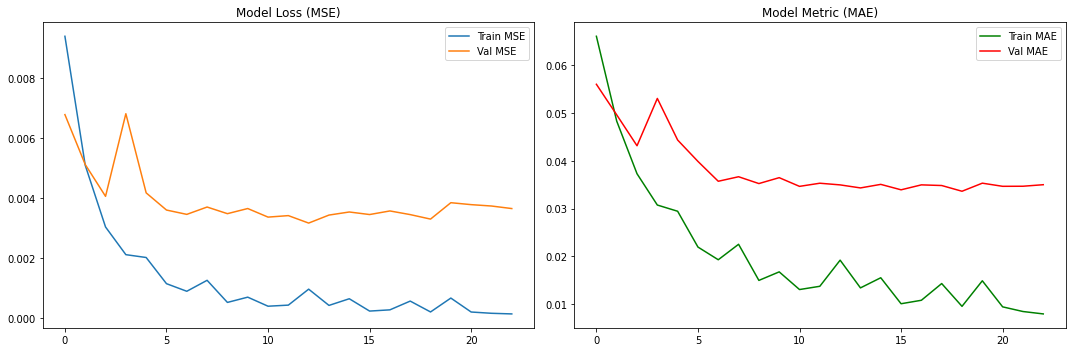

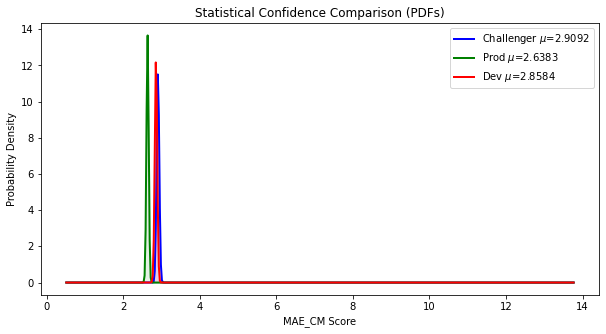

Error: operands could not be broadcast together with shapes (3284,) (3809,) 


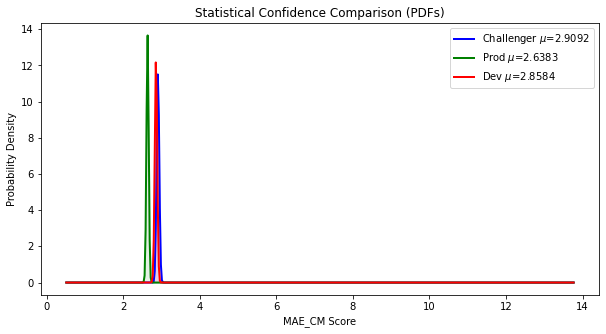

Error: operands could not be broadcast together with shapes (3284,) (3809,) 
🚀 Challenger is statistically superior (p=1.0000)

--- Comparing Registry Aliases ---


Comparing 2.9092311399572512 < 2.8583851269018186
❌ Did not beat current @dev.
🏃 View run Z-Depth-Training-LSTM at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0/runs/147d6805e1ac48888d5266506ddf60fc
🧪 View experiment at: https://dagshub.com/SamuelFredricBerg/4dt907.mlflow/#/experiments/0


In [ ]:
import sys
sys.path.append("../../scripts")

import dagshub
import mlflow
import ml_utils as mlutils

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt

# --- 1. SETUP DAGSHUB & CONFIG ---
dagshub.init(repo_owner="SamuelFredricBerg", repo_name="4dt907", mlflow=True)
# New Name for the Z-Predictor Project
project_name = "Project_Model_Z_Predictor_V2"
utils = mlutils.mlutils(project_name)

import random


config = {
    "variant": "LSTM-Z-Lifting-Mirror-Augmentation",
    "seq_length": 30,
    "batch_size": 32,
    "hidden_size": 256,
    "num_layers": 2,
    "learning_rate": 0.001,
    "rnn_type": 'LSTM',


    "epochs": 50,
    "patience": 10,
    "seed": 42
}
SEED = config["seed"]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- 2. DATASET & MODEL CLASSES ---
class KinectFolderDataset(Dataset):
    def __init__(self, file_paths, seq_length=30):
        self.X_seqs = []
        self.y_seqs = []
        self.seq_length = seq_length

        for path in file_paths:
            df = pd.read_csv(path)
            all_cols = [c for c in df.columns if c != 'FrameNo']
            x_y_cols = sorted([c for c in all_cols if c.endswith('_x') or c.endswith('_y')])
            z_cols = sorted([c for c in all_cols if c.endswith('_z')])
            
            x_data = df[x_y_cols].values.astype(np.float32)
            y_data = df[z_cols].values.astype(np.float32)
            
            if len(df) >= seq_length:
                for i in range(len(df) - seq_length + 1):
                    self.X_seqs.append(x_data[i : i + seq_length])
                    self.y_seqs.append(y_data[i : i + seq_length])
            
    def __len__(self): return len(self.X_seqs)
    def __getitem__(self, idx):
        return torch.tensor(self.X_seqs[idx]), torch.tensor(self.y_seqs[idx])

class PoseLiftingModel(nn.Module):
    def __init__(self, input_size=26, hidden_size=128, num_layers=2, output_size=13, rnn_type='LSTM'):
        super(PoseLiftingModel, self).__init__()
        if rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.relu(out)
        return self.fc(out)

# --- 3. DATA PREP (Professional File-Level Split) ---
folder = "../../data/kinect_good_preprocessed_A9_mediapipe"
all_files = sorted(glob.glob(os.path.join(folder, "*.csv")))

# 1. Isolate originals to prevent Subject A and Mirrored Subject A being in different sets
originals = [f for f in all_files if "_mirrored" not in f]
np.random.seed(config["seed"])
np.random.shuffle(originals)

# 1. Determine number of files for each set (10% Test, 10% Val, 80% Train)
num_total = len(all_files)
# You can use your config here:
num_test = int(0.1 * num_total)
num_val = int(0.1 * num_total)

test_files_orig = originals[:num_test]
val_files_orig = originals[num_test : num_test + num_val]
train_files_orig = originals[num_test + num_val:]

# 3. Add mirrors back into Training and Validation ONLY
def add_mirrors(file_list):
    augmented = []
    for f in file_list:
        augmented.append(f)
        mirror = f.replace(".csv", "_mirrored.csv")
        if os.path.exists(mirror):
            augmented.append(mirror)
    return augmented

train_files = add_mirrors(train_files_orig)
val_files = add_mirrors(val_files_orig)
test_files = test_files_orig 

print(f"📁 Total Files: {num_total}")
print(f"🔒 Test Files ({len(test_files)}): {[os.path.basename(f) for f in test_files]}")
print(f"🧪 Val Files:  {len(val_files)}")
print(f"✅ Train Files: {len(train_files)}")

# 3. Create three separate datasets (No more random_split on segments!)
train_dataset = KinectFolderDataset(train_files, seq_length=config["seq_length"])
val_dataset   = KinectFolderDataset(val_files, seq_length=config["seq_length"])
test_dataset  = KinectFolderDataset(test_files, seq_length=config["seq_length"])

# 4. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)

# --- 4. MAIN TRAINING WITH MLFLOW ---
with mlflow.start_run(run_name="Z-Depth-Training-LSTM") as run:
    mlflow.log_params(config)
    
    model = PoseLiftingModel(
        input_size=26, 
        hidden_size=config["hidden_size"], 
        num_layers=config["num_layers"], 
        output_size=13, 
        rnn_type=config["rnn_type"]
    )
    criterion = nn.MSELoss() 
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])


    history = {
        'train_mse': [], 
        'val_mse': [], 
        'train_mae': [], 
        'val_mae': []
    }
    best_val_loss = float('inf')
    counter = 0

    for epoch in range(config["epochs"]):
        model.train()
        train_running_loss = 0.0
        train_running_mae = 0.0
        
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_running_loss += loss.item()
            train_running_mae += torch.mean(torch.abs(outputs - targets)).item()
        
        model.eval()
        val_running_loss = 0.0
        val_running_mae = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                v_loss = criterion(outputs, targets)
                val_running_loss += v_loss.item()
                val_running_mae += torch.mean(torch.abs(outputs - targets)).item()
                
        # Calculate Averages
        metrics = {
            "Train_MSE": train_running_loss / len(train_loader),
            "Val_MSE": val_running_loss / len(val_loader),
            "Train_MAE": train_running_mae / len(train_loader),
            "Val_MAE": val_running_mae / len(val_loader)
        }
        
        metrics = {
            "Train_MSE": train_running_loss / len(train_loader),
            "Val_MSE": val_running_loss / len(val_loader),
            "Train_MAE": train_running_mae / len(train_loader),
            "Val_MAE": val_running_mae / len(val_loader)
        }

        # This loop now correctly finds 'train_mse', 'val_mse', etc.
        for k, v in metrics.items():
            history[k.lower()].append(v)
            
        mlflow.log_metrics(metrics, step=epoch)

        print(f"Epoch {epoch}: Train MSE {metrics['Train_MSE']:.6f}, Val MAE {metrics['Val_MAE']:.6f}")

        # Early Stopping Logic
        if metrics["Val_MSE"] < best_val_loss:
            best_val_loss = metrics["Val_MSE"]
            counter = 0
            torch.save(model.state_dict(), 'best_model.pth')
        else:
            counter += 1
            if counter >= config["patience"]:
                print("Early stopping triggered.")
                break

    # --- 5. PLOTS & ARTIFACTS ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(history['train_mse'], label='Train MSE'); ax1.plot(history['val_mse'], label='Val MSE')
    ax1.set_title('Model Loss (MSE)'); ax1.legend()
    
    ax2.plot(history['train_mae'], label='Train MAE', color='green'); ax2.plot(history['val_mae'], label='Val MAE', color='red')
    ax2.set_title('Model Metric (MAE)'); ax2.legend()
    
    plt.tight_layout()
    plt.savefig("z_learning_plots.png")
    mlflow.log_artifact("z_learning_plots.png")

    # Final Summary Table (CSV)
    summary_df = pd.DataFrame(history)
    summary_df.to_csv("training_history.csv", index=False)
    mlflow.log_artifact("training_history.csv")

    # --- 5. PER-JOINT EVALUATION (Add this to your main script) ---
    print("\n--- Running Final Evaluation on  Sequences ---")
    
    # Names of the 13 joints
    joint_names = [
        "nose", "left_shoulder", "left_elbow", "right_shoulder", "right_elbow",
        "left_wrist", "right_wrist", "left_hip", "right_hip", "left_knee", 
        "right_knee", "left_ankle", "right_ankle"
    ]

    all_seq_errors = []
    # Dictionary to track errors per joint across all test samples
    joint_error_accumulator = {name: [] for name in joint_names}

    model.eval() # Ensure model is in eval mode
    with torch.no_grad():
        for inputs, targets in test_loader:
            # Move to device if you're using GPU
            predictions = model(inputs)
            
            # 1. Sequence-wide Mean Error
            dist_cm = torch.abs(predictions - targets) * 100
            all_seq_errors.append(torch.mean(dist_cm).item())
            
            # 2. Per-Joint Error (Mean across Batch and Sequence dims)
            # dist_cm shape is [Batch, Seq, Joints]
            error_per_joint = torch.mean(dist_cm, dim=(0, 1)).cpu().numpy()
            
            for i, name in enumerate(joint_names):
                joint_error_accumulator[name].append(error_per_joint[i])

    # Calculate Aggregates
    grand_average = np.mean(all_seq_errors)
    std_dev = np.std(all_seq_errors)
    
    # Calculate Mean error per joint
    mean_joint_errors = {name: np.mean(joint_error_accumulator[name]) for name in joint_names}

    # --- 6. LOG TO DAGSHUB ---
    # Log the summary stats
    mlflow.log_metrics({
        "Grand_Avg_Test_MAE_cm": grand_average,
        "Test_MAE_StdDev": std_dev
    })
    
    # Log individual joint errors (extremely useful for DagsHub table comparison)
    mlflow.log_metrics({f"Joint_Err_{k}": v for k, v in mean_joint_errors.items()})

    # Save a CSV artifact for the full report
    report_df = pd.DataFrame.from_dict(mean_joint_errors, orient='index', columns=['Mean_Error_cm'])
    report_df.to_csv("per_joint_evaluation.csv")
    mlflow.log_artifact("per_joint_evaluation.csv")

    print(f"Evaluation Complete. Grand Avg Error: {grand_average:.3f} cm")

    # --- Calculate Trainable Parameters ---
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {trainable_params:,}")

    # Optional: Log this to MLflow so you can see it in your DagsHub table
    mlflow.log_param("trainable_params", trainable_params)

    # --- 7. PREPARE SCORES FOR STATISTICAL COMPARISON ---
    # Convert your list of 10 sequence errors into a DataFrame
    current_scores_df = pd.DataFrame({
        'mae_cm': all_seq_errors  # This matches the 'metric' name we will pass
    })
    
    # Save this to CSV so the 'compare' methods can download it later
    current_scores_df.to_csv("cv_fold_scores.csv", index=False)
    mlflow.log_artifact("cv_fold_scores.csv")

    # --- 8. STATISTICAL RADIOGRAPH (T-Test) ---
    # We pass metric="mae_cm" to match the column name above
    is_better, p_val = utils.is_challenger_statistically_better(
        current_scores_df, 
        metric="mae_cm"
    )




    # SAFE LOGGING: Only log if files exist (they won't on the very first run)
    import os
    if os.path.exists("model_confidence_comparison.png"):
        mlflow.log_artifact("model_confidence_comparison.png")
    
    if os.path.exists("challenger_vs_prod_ttest.png"):
        mlflow.log_artifact("challenger_vs_prod_ttest.png")

    if is_better:
        print(f"🚀 Challenger is statistically superior (p={p_val:.4f})")
    else:
        print(f"⚠️ Difference not significant or model is worse (p={p_val:.4f})")

    # --- 9. REGISTRY VALIDATION ---
    # This uses your new function to pull @prod and @dev and test them 
    # against the CURRENT test_loader
    print("\n--- Comparing Registry Aliases ---")
    registry_results = utils.compare_pytorch_aliases(test_loader, joint_names)
    
    # Optional: Log the average of these registry results to MLflow
    for alias, scores in registry_results.items():
        if scores is not None:
            mlflow.log_metric(f"Registry_{alias}_Mean_MAE", np.mean(scores))

    # --- 6. CHALLENGER CHECK ---
    # We use Val_MAE as the deciding metric for depth accuracy
    if utils.auto_check_challenger(run.info.run_id, metric_name="Grand_Avg_Test_MAE_cm"):
        # Log the PyTorch model
        mlflow.pytorch.log_model(model, "model", registered_model_name=project_name)
        
        # Set dev alias
        latest_v = utils.client.get_latest_versions(project_name)[0].version
        utils.client.set_registered_model_alias(project_name, "dev", latest_v)
        print("🚀 New model beat @dev! Registered and aliased.")
    else:
        print("❌ Did not beat current @dev.")